# EZyRB Tutorial 4
## Build a Multi Reduced Order Model (MultiROM)

In this tutorial, we will show how to aggregate the predictions of different ROMs following the method presented in the [paper by Ivagnes et al.](https://link.springer.com/content/pdf/10.1007/s00707-024-04007-9.pdf)

Let's call $\boldsymbol{\eta}=(\boldsymbol{x}, \boldsymbol{\mu})$ the problem's features, namely the space coordinates and the parameters.

The idea is to build and combine a set of ROMs $\{\mathcal{M}_1, \mathcal{M}_2, \dots, \mathcal{M}_{N}\}$, to approximate a specific high-fidelity field, for instance the parametrized velocity $\boldsymbol{u}(\boldsymbol{\eta})$. The individual ROMs differ in the reduction approach and/or in the approximation technique. The **MultiROM prediction** will then be a convex combination of the predictions of the pre-trained individual ROMs. If the $i$-th ROM prediction is $\tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta})$, then the MultiROM prediction will be:
$$\tilde{\boldsymbol{u}}(\boldsymbol{\eta}) = \sum_{i=1}^{N} w^{(i)}(\boldsymbol{\eta}) \tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}) ,$$
where the weights associated with each ROM in the convex combination are space- and parameter-dependent. In this way, the **MultiROM** should effectively and automatically identify the ROM with the optimal performance across various regions of the spatial and parameter domains.

To build the model, we have to design a method to compute the weights, also in unseen settings.
We here consider a dataset from the library **Smithers** (`NavierStokesDataset`), and we divide it into three subsets:
- the **training** dataset (composed of $M_{\text{train}}$ instances): used to train the individual ROMs;
- the **evaluation** dataset (composed of $M_{\text{evaluation}}$ instances): used to compute the optimal weights;
- the **test** dataset (composed of $M_{\text{test}}$ instances): used to test our methodology, where the weights are approximated with a regression technique.

Now the question is: *How to compute the weights?*
We here consider two different approaches:
- **XMA** (as in [de Zordo-Banliat et al.](https://www.sciencedirect.com/science/article/abs/pii/S0021999123007234)), where the weights are computed in the evaluation set, using the following expression:
  $$w^{(i)}(\boldsymbol{\eta})=\dfrac{g^{(i)}(\boldsymbol{\eta})}{\sum_{i=1}^N g^{(i)}(\boldsymbol{\eta})}, \, g^{(i)}(\boldsymbol{\eta})=\text{exp}\left( - \dfrac{1}{2} \dfrac{(\tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}) - \boldsymbol{u}(\boldsymbol{\eta}))^2}{\sigma^2} \right),\, \text{for } \boldsymbol{\eta}=\boldsymbol{\eta}_{\text{evaluation}}.
  $$ In the test set, a regression approach (`KNN`) is used to approximate the weights at unseen $\boldsymbol{\eta}=\boldsymbol{\eta}_{\text{test}}$.   

- **ANN**: a neural network takes as input $\boldsymbol{\eta}$, and gives as output directly the weights $w^{(i)}, i=1, \dots, N,$ of the convex combination. It is trained to minimize the following loss:
$$\mathcal{L}=\frac{1}{M_{\textrm{test}}} \sum_{j=1}^{M_{\textrm{test}}}\left(\sum_{i=1}^N \left(w^{(i)}(\boldsymbol{\eta}_j) \tilde{\boldsymbol{u}}^{(i)}(\boldsymbol{\eta}_j)\right) - \boldsymbol{u}(\boldsymbol{\eta}_j) \right)^2$$

Let's begin the tutorial with some useful imports.

In [1]:
import numpy as np
import copy
%pip install -e ../
from ezyrb import Database
from ezyrb import POD, AE, PODAE
from ezyrb import RBF, GPR, ANN, KNeighborsRegressor
from ezyrb import ReducedOrderModel as ROM
from ezyrb import MultiReducedOrderModel as MultiROM
from ezyrb.plugin import Aggregation, DatabaseSplitter
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from matplotlib.colors import LogNorm
import matplotlib.tri as tri
import matplotlib
from mpl_toolkits.axes_grid1 import make_axes_locatable

Obtaining file:///Users/aivagnes/Desktop/Work/Packages/EZyRB
  Preparing metadata (setup.py) ... done
  Attempting uninstall: ezyrb
    Found existing installation: ezyrb 1.3.0
    Uninstalling ezyrb-1.3.0:
      Successfully uninstalled ezyrb-1.3.0
  Running setup.py develop for ezyrb

[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Before starting with the core part of the tutorial, we define a useful function for plotting the solutions on a 2D mesh.

In [2]:
def plot_multiple_internal(db, fields_list, titles_list, figsize=None,
                           logscale=False, lim_x=(-0.5, 2), lim_y=(-1, 1),
                           different_cbar=True, clims=None):
    '''
    Plot multiple internal fields in one figure.

    Parameters
    ----------
    db : PinaDataModule
        The data module.
    fields_list : list
        The list of fields to plot.
    titles_list : list
        The list of titles for each field.
    figsize : tuple (optional, default=(16, 16/len(fields_list))
        The size of the figure.
    logscale : bool (optional, default=False)
        Whether to use a logarithmic color scale.
    lim_x : tuple (optional, default=(-0.5, 2))
        The x-axis limits.
    lim_y : tuple (optional, default=(-1, 1))
        The y-axis limits.
    different_cbar : bool (optional, default=True)
        Whether to use a different colorbar for each field.

    Returns
    ----------
    None (shows figures)
    '''
    triang = db.auxiliary_triang
    
    if figsize is None:
        figsize = (16, 16/len(fields_list))
    fig, axs = plt.subplots(1, len(fields_list), figsize=figsize)
    for e, a in enumerate(axs):
        field = fields_list[e]
        title = titles_list[e]
        if clims is None:
            clims = fields_list[0].min(), fields_list[0].max()
        if logscale:
            lognorm = matplotlib.colors.LogNorm(vmin=clims[0]+1e-12,
                vmax=clims[1])
            c = a.tripcolor(triang, field, cmap='rainbow',
                shading='gouraud', norm=lognorm)
        else:
            c = a.tripcolor(triang, field, cmap='rainbow',
                shading='gouraud', vmin=clims[0],
                vmax=clims[1])
        a.plot(db._coords_airfoil()[0], db._coords_airfoil()[1],
            color='black', lw=0.5)
        a.plot(db._coords_airfoil(which='neg')[0],
            db._coords_airfoil(which='neg')[1],
            color='black', lw=0.5)
        a.set_aspect('equal')
        if lim_x is not None:
            a.set_xlim(lim_x)
        if lim_y is not None:
            a.set_ylim(lim_y)
        if title is not None:
            a.set_title(title)
        if different_cbar:
            divider = make_axes_locatable(a)
            cax = divider.append_axes("right", size= "5%", pad=0.1)
            plt.colorbar(c, cax=cax)
        a.set_xticks([])
        a.set_yticks([])
    if not different_cbar:
        divider = make_axes_locatable(axs[0])
        cax = divider.append_axes("left", size= "1%", pad=0.1)
        plt.colorbar(c, cax=cax)
    plt.tight_layout()
    plt.show()

Now, we define a simple neural network class, which will be useful in the multiROM-ANN case. This networks takes as input the spatial coordinates and the problem parameters, and gives as output the weights of our multiROM. This class is inherited from the `ANN` one, with a newly defined `fit` function. In this case, in the loss function we have the discrepancy between the multiROM prediction and the FOM reference. Moreover, the power of this technique is that it is continuous in space, so we can train the NN on a reduced amount of spatial data, gaining time also in the training itself.

In [3]:
class ANN_weights(ANN):
    def __init__(self, mrom, layers, function, stop_training, loss=None,
                 optimizer=torch.optim.Adam, lr=0.001, l2_regularization=0,
                 frequency_print=500, last_identity=True):
        super().__init__(layers, function, stop_training, loss=None,
                 optimizer=torch.optim.Adam, lr=0.001, l2_regularization=0,
                 frequency_print=10, last_identity=True)

        # import useful data from multirom and roms predictions
        self.mrom = mrom
        self.params = list(self.mrom.roms.values())[0].validation_full_database.parameters_matrix
        
        self.frequency_print = frequency_print
        self.lr = lr
        self.l2_regularization = l2_regularization

        # import ROMs and validation predictions of all ROMs
        self.rom_validation_predictions = {}
        for rom in self.mrom.roms:
            rom_pred = self.mrom.roms[rom]
            rom_pred = rom_pred.predict(self.params)
            rom_pred = rom_pred.reshape(rom_pred.shape[0]*rom_pred.shape[1], 1)
            self.rom_validation_predictions[rom] = self._convert_numpy_to_torch(rom_pred)
            
        # Device configuration
        self.device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
        print(f"Using device: 💻 {self.device}")
        
    def _build_model_(self, points):
        layers = self.layers.copy()
        layers.insert(0, points.shape[1])
        layers.append(len(self.mrom.roms))
        self.model = self._list_to_sequential(layers, self.function)
        
        # Move the model to the device
        self.model.to(self.device)

    def fit(self, points, values): # points=(x, mu) and values=(snapshots)
        self._build_model_(points)
        optimizer = self.optimizer(
            self.model.parameters(),
            lr=self.lr, weight_decay=self.l2_regularization)
        
        #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.9, patience=1000)

        points = self._convert_numpy_to_torch(points)
        values = self._convert_numpy_to_torch(values)
        
        # Move everything to the device
        points = points.to(self.device)
        values = values.to(self.device)
        self.rom_validation_predictions = {rom: pred.to(self.device) for rom, pred in self.rom_validation_predictions.items()}

        # train the neural network
        n_epoch = 1
        flag = True
        while flag:
            # compute output of ANN
            y_pred = self.model(points)

            # compute aggregated solution from output weights of ANN
            aggr_pred = torch.zeros(values.shape, device=self.device)
            for i, rom in enumerate(self.mrom.roms):
                weight = y_pred.clone()[..., i].unsqueeze(-1)
                aggr_pred += weight*self.rom_validation_predictions[rom]

            # difference between aggregated solution and exact solution
            loss = self.loss(aggr_pred, values)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            scalar_loss = loss.item()
            self.loss_trend.append(scalar_loss)
            
            #scheduler.step(scalar_loss)

            for criteria in self.stop_training:
                if isinstance(criteria, int):  # stop criteria is an integer
                    if n_epoch == criteria:
                        flag = False
                elif isinstance(criteria, float):  # stop criteria is float
                    if scalar_loss < criteria:
                        flag = False

            if (flag is False or
                    n_epoch == 1 or n_epoch % self.frequency_print == 0):
                print(f'[epoch {n_epoch:6d}]\t{scalar_loss:e}')
            n_epoch += 1

        return optimizer

    def predict(self, x):
        
        # Move the model to the device
        x = self._convert_numpy_to_torch(np.array(x))
        x = x.to(self.device)
        y_new = self.model(x)
        ynew = y_new.cpu().detach().numpy()
        return ynew

Now we can introduce the dataset, taken from the library [Smithers](https://github.com/mathLab/Smithers).

The test case here considered is `AirfoilTransonicDataset`, namely the transonic flow over an airfoil (NACA 0012), with the angle of attack varying in the range [$0^{\circ}$, $10^{\circ}$] at the Reynolds number $Re=10^7$.

This test case is quite challenging, as it presents shocks, and the shock position varies a lot from one snapshot to the other.
The full order implementation has been done in OpenFOAM (using a finite volume discretization) and has been validated with the results in https://ntrs.nasa.gov/citations/19850019511 and in https://doi.org/10.2514/1.J051329.

The `AirfoilTransonicDataset` is a dictionary including:

*   `pts_coordinates`: the points' coordinates, divided into:
    * `pts_coordinates['internal']`: x-y coordinates in internal mesh;
    * `pts_coordinates['airfoil']`: x-y coordinates on the airfoil;

*   `params`: the parameters, in our case only the angle of attack;
*   `snapshots`: the snapshots' fields, divided into:
    * `snapshots['internal']`: the fields evaluated on the 2D internal mesh (we will focus on the velocity magnitude `mag(v)`);
    * `snapshots['airfoil']`: the fields on the airfoil (1D fields).

We focus here on the 2D `mag(v)` field.
Let's try to read the dataset!

In [4]:
from smithers.dataset import NavierStokesDataset, AirfoilTransonicDataset
data = AirfoilTransonicDataset()
field = 'mag(v)'
coords = data.pts_coordinates["internal"].T 
params = data.params
snaps = data.snapshots["internal"][field]
snaps_max = np.max(snaps)
snaps /= snaps_max
print("Shape of parameters vector: ", params.shape)
print("Shape of snapshots matrix: ", snaps.shape)

Shape of parameters vector:  (100, 1)
Shape of snapshots matrix:  (100, 45448)


Let's try now to visualize the 2D spatial coordinates and the velocity magnitude snapshots for the two extreme parameters.

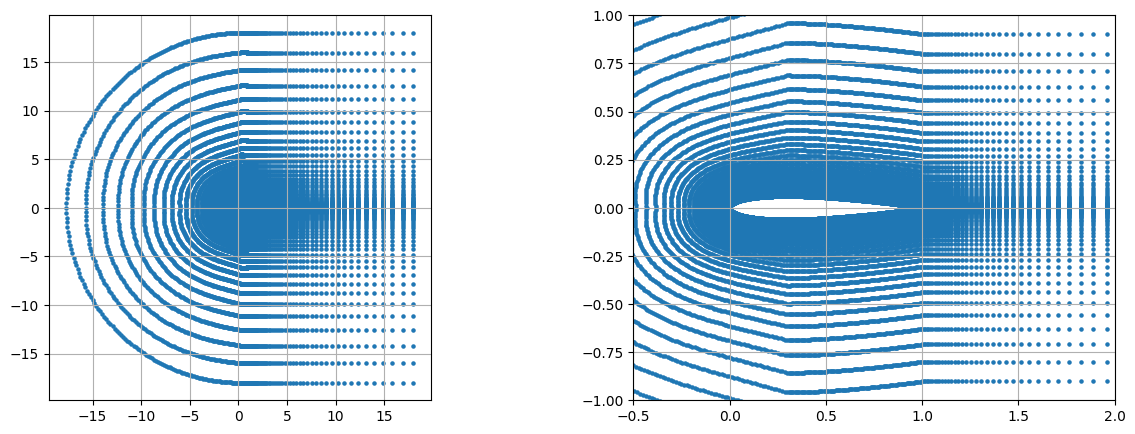

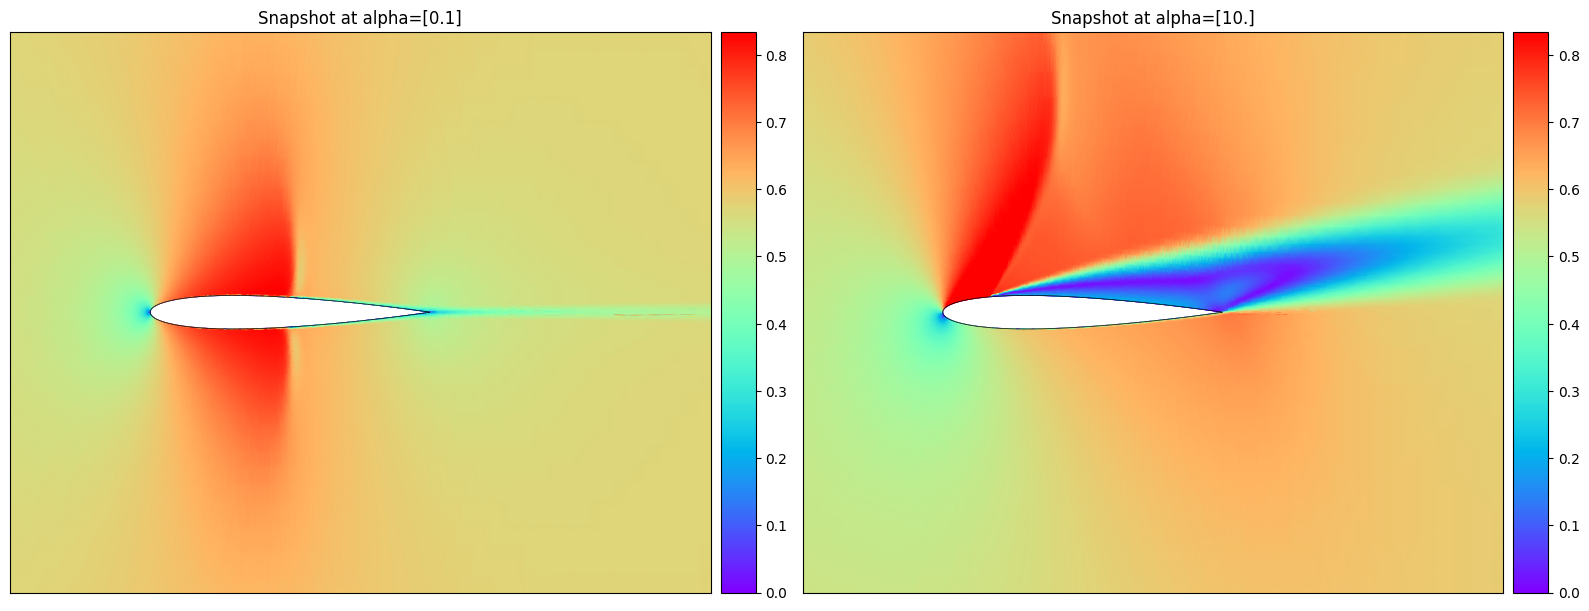

In [5]:
idx = 0
# Plot coordinates
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(data.pts_coordinates["internal"][0, :],
            data.pts_coordinates["internal"][1, :], s=5)
ax[1].scatter(data.pts_coordinates["internal"][0, :],
            data.pts_coordinates["internal"][1, :], s=5)
ax[1].set_xlim(-0.5, 2)
ax[1].set_ylim(-1, 1)

for a in ax:
  a.grid()
  a.set_aspect("equal")
plt.show()
plot_multiple_internal(data, [snaps[0], snaps[-1]], [f"Snapshot at alpha={params[0]}", f"Snapshot at alpha={params[-1]}"],
                      figsize=None, logscale=False, lim_x=(-0.5, 2), lim_y=(-1, 1), different_cbar=True)

Then, we can create the database for the ROMs and initialize the reduction and approximation approaches. Here, we decide to consider POD and PODAE as reduction techniques, RBF and GPR as approximation strategies. In the end, we are considering four ROMs: POD-RBF, POD-GPR, PODAE-RBF, PODAE-GPR. 

In [6]:
# Create the database
db_all = Database(params, snaps, coords)

# Define some reduction and approximation methods to test
rank = 3
pod_for_podae = POD('svd', rank=80)
ae_for_podae = AE([30, 10, rank], [rank, 10, 30], nn.Softplus(), nn.Softplus(), 50000, lr=1e-3, frequency_print=2000)
reduction_methods = {
    'POD': POD('svd', rank=rank),
    'PODAE': PODAE(pod_for_podae, ae_for_podae)
}
approximation_methods = {
    'RBF': RBF(),
    'GPR': GPR()
}

We now define the ROMs (store into a simple dictionary). Note that we use the `DatabaseSplitter` plugin to split our database into train, validation, test, and predict sets. Here we will only use the train, validation, and predict sets.

In [7]:
# Define a dictionary to store the ROMs
roms_dict = {}
db_splitter_plugin = DatabaseSplitter(train=0.6, validation=0.3, test=0.,
                                            predict=0.1, seed=42)
# Train a ROM for each combination of reduction and approximation
for redname, redclass in reduction_methods.items():
    for approxname, approxclass in approximation_methods.items():
        rom = ROM(copy.deepcopy(db_all),
                  copy.deepcopy(redclass),
                  copy.deepcopy(approxclass),
                  plugins=[db_splitter_plugin])
        roms_dict[f'{redname}_{approxname}'] = rom

Then, the definition of the `MultiROM` follows. We can now fit the MultiROM, which coincides with fitting the individual ROMs separately.

In [8]:
# Build a simple multiROM without aggregation and save it
multirom_noagg = MultiROM(roms_dict)
# Fit the multiROM (this step may take some time)
multirom_noagg.fit()

[epoch      1]	2.469141e+02
[epoch   2000]	1.377898e-01
[epoch   4000]	1.071991e-01
[epoch   6000]	7.265408e-02
[epoch   8000]	4.396581e-02
[epoch  10000]	3.937927e-02
[epoch  12000]	3.674430e-02
[epoch  14000]	4.076399e-02
[epoch  16000]	2.940542e-02
[epoch  18000]	2.764397e-02
[epoch  20000]	2.988867e-02
[epoch  22000]	2.159446e-02
[epoch  24000]	2.006776e-02
[epoch  26000]	1.967250e-02
[epoch  28000]	1.194988e-02
[epoch  30000]	9.829493e-03
[epoch  32000]	9.823296e-03
[epoch  34000]	8.634089e-03
[epoch  36000]	8.533438e-03
[epoch  38000]	8.409876e-03
[epoch  40000]	1.002743e-02
[epoch  42000]	1.035028e-02
[epoch  44000]	8.028184e-03
[epoch  46000]	8.383193e-03
[epoch  48000]	7.963227e-03
[epoch  50000]	1.061061e-02
[epoch      1]	2.433394e+02
[epoch   2000]	2.430486e-01
[epoch   4000]	8.800354e-02
[epoch   6000]	6.279282e-02
[epoch   8000]	4.753726e-02
[epoch  10000]	4.444053e-02
[epoch  12000]	4.448576e-02
[epoch  14000]	4.391388e-02
[epoch  16000]	4.341885e-02
[epoch  18000]	3.927

After fitting the individual models in the train database, we can now read the validation and test databases, and, for example, visualize the ROM predictions for some test parameters.

In [9]:
# Get the dictionary of ROMs
roms_dict = multirom_noagg.roms

# Extract one ROM from the dictionary, and read the validation and test databases
rom_one = list(multirom_noagg.roms.values())[0]
db_validation = rom_one.validation_full_database
db_test = rom_one.predict_full_database

Test parameter for plotting:  [0.2]


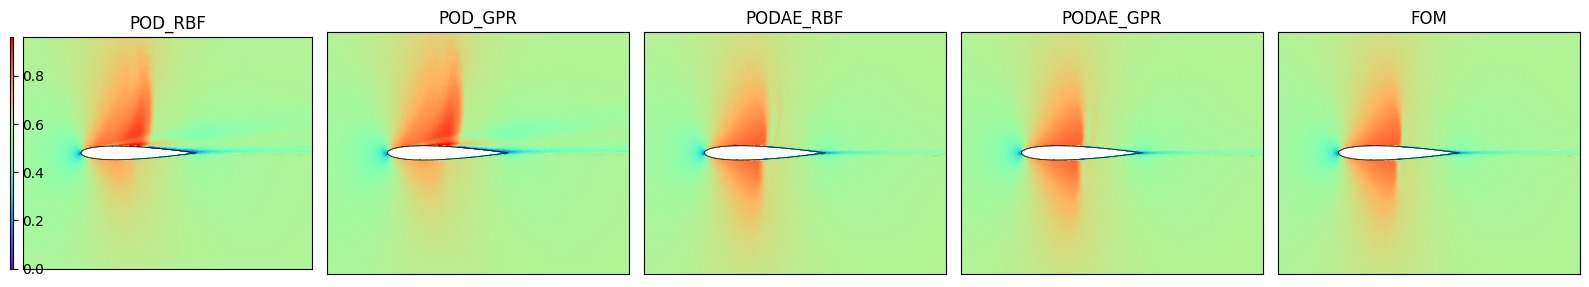

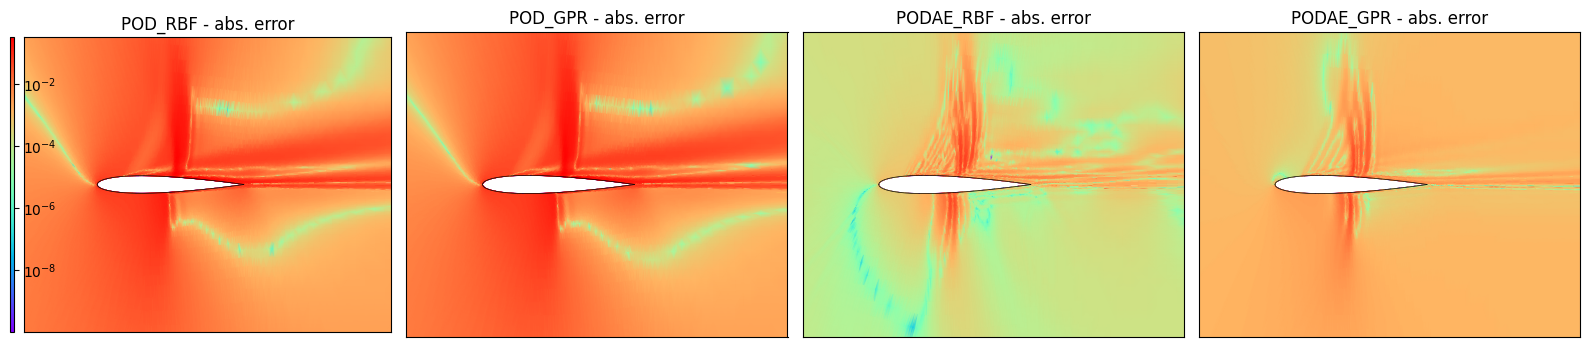

In [10]:
# Visualize the results of each ROM in the multiROM without aggregation on
# a new parameter
j = 0 # we choose an index to plot the solution and the weights
p = db_test.parameters_matrix[j]
print("Test parameter for plotting: ", p)
fields = []
roms_pred = [rom.predict([p]).flatten() for rom in roms_dict.values()]
roms_pred.append(db_test.snapshots_matrix[j])
errs = [np.abs(r - db_test.snapshots_matrix[j])+1e-10 for r in roms_pred[:-1]]
labels = [f'{key}' for key in roms_dict.keys()]
labels.append("FOM")
plot_multiple_internal(data, roms_pred, labels, different_cbar=False)
plot_multiple_internal(data, errs, [f"{l} - abs. error" for l in labels], logscale=True, different_cbar=False)

We can see that the `POD_*` solutions are more overdiffusive, while the `PODAE_*` solutions better capture the discontinuity, even if they still exhibit imprecisions.

We now initialize two novel `multiROM`s using the plugin `Aggregation`. One model is for the standard XMA aggregation (indicated with `fit_function=None`) and uses `KNN` as regressor. The other model uses the `ANN_weights` class to compute the weights starting from the individual ROM prediction. In both cases, the weights are trained in the validation set.

In [11]:
print("Fitting multiROM with KNN aggregation...")
knn = KNeighborsRegressor()
multirom_KNN = MultiROM(roms_dict, plugins=[Aggregation(fit_function=None, predict_function=knn), db_splitter_plugin])
multirom_KNN.fit()

Fitting multiROM with KNN aggregation...
Optimal sigma value in weights:  [0.009994]


In [12]:
print("Fitting multiROM with ANN aggregation...")
ann = ANN_weights(multirom_noagg, [64, 64, 64],[nn.Softplus(), nn.Softplus(), nn.Softplus(), nn.Softmax(dim=-1)],
                    stop_training=1000, lr=1e-3, frequency_print=100, l2_regularization=0)
multirom_ANN = MultiROM(roms_dict, plugins=[Aggregation(fit_function=ann), db_splitter_plugin])
multirom_ANN.fit()

Fitting multiROM with ANN aggregation...
Using device: 💻 mps
[epoch      1]	1.110127e-04
[epoch    100]	2.332629e-05
[epoch    200]	2.292044e-05
[epoch    300]	2.286620e-05
[epoch    400]	2.281346e-05
[epoch    500]	2.274650e-05
[epoch    600]	2.265942e-05
[epoch    700]	2.256762e-05
[epoch    800]	2.250623e-05
[epoch    900]	2.247204e-05
[epoch   1000]	2.244576e-05


Let's now quantify the relative error on test parameters for the individual ROMs and for the multiROM strategies.

In [13]:
multiroms = {}
multiroms["KNN"] = multirom_KNN
multiroms["ANN"] = multirom_ANN

header = '{:10s}'.format('')
for name in approximation_methods:
    header += ' {:>16s}'.format(name)
print(header)
for redname, redclass in reduction_methods.items():
    row = '{:10s}'.format(redname)
    for approxname, approxclass in approximation_methods.items():
        rom = roms_dict[redname+'_'+approxname]
        row += ' {:16e}'.format(rom.test_error(db_test))
    print(row)
    print('-'*len(row))
for model_name in multiroms:
    row = '{:10s}'.format(model_name)
    multirom_ = multiroms[model_name]
    row += '- MultiROM {:16e}'.format(multirom_.test_error(db_test))
    print(row)

                        RBF              GPR
POD            5.263353e-02     5.263348e-02
--------------------------------------------
PODAE          9.785834e-03     9.695809e-03
--------------------------------------------
KNN       - MultiROM     1.304681e-02
ANN       - MultiROM     9.233725e-03


We can try now to visualize the predicted multiROMs solutions for a test parameters, and the errors with respect to the corresponding FOM reference. The multiROM automatically detects the best method in different spatial coordinates.

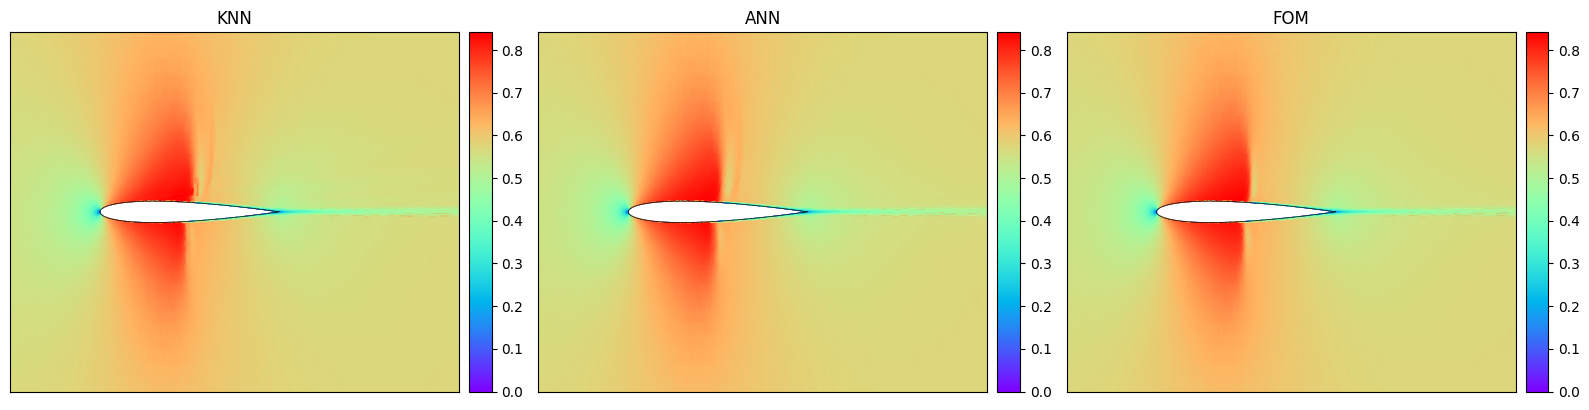

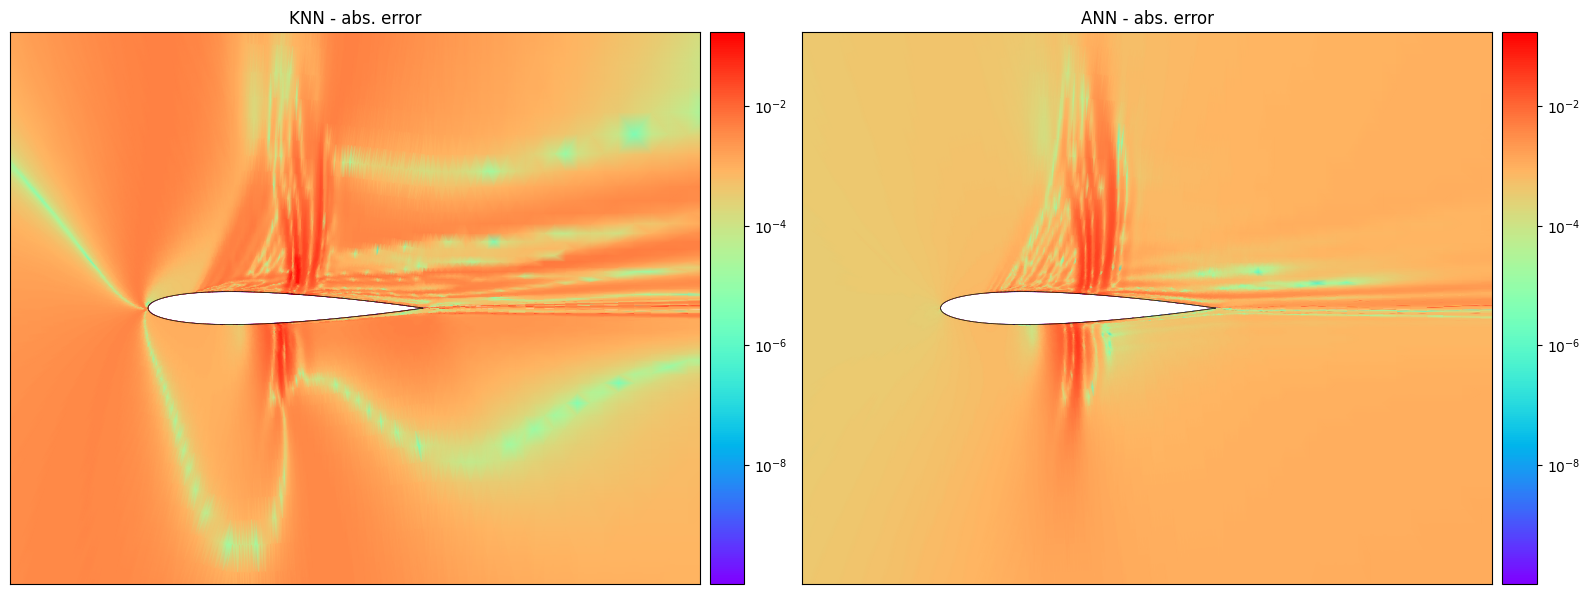

In [14]:
fields = []
roms_pred = []
for rom in multiroms.values():
    roms_pred.append(rom.predict(np.array([p]).reshape(-1, 1)).flatten())
roms_pred.append(db_test.snapshots_matrix[j].flatten())
errs = [np.abs(r - db_test.snapshots_matrix[j])+1e-10 for r in roms_pred[:-1]]
labels = list(multiroms.keys())
labels.append("FOM")
# visualize fields
plot_multiple_internal(data, roms_pred, labels,
            figsize=None, logscale=False, lim_x=(-0.5, 2), lim_y=(-1, 1))
# visualize errors in log scale
plot_multiple_internal(data, errs, [f"{l} - abs. error" for l in labels],
            figsize=None, logscale=True, lim_x=(-0.5, 2), lim_y=(-1, 1))

We finally try to visualize the weights, for example for the standard XMA multiROM strategy, for the same test parameter as before.

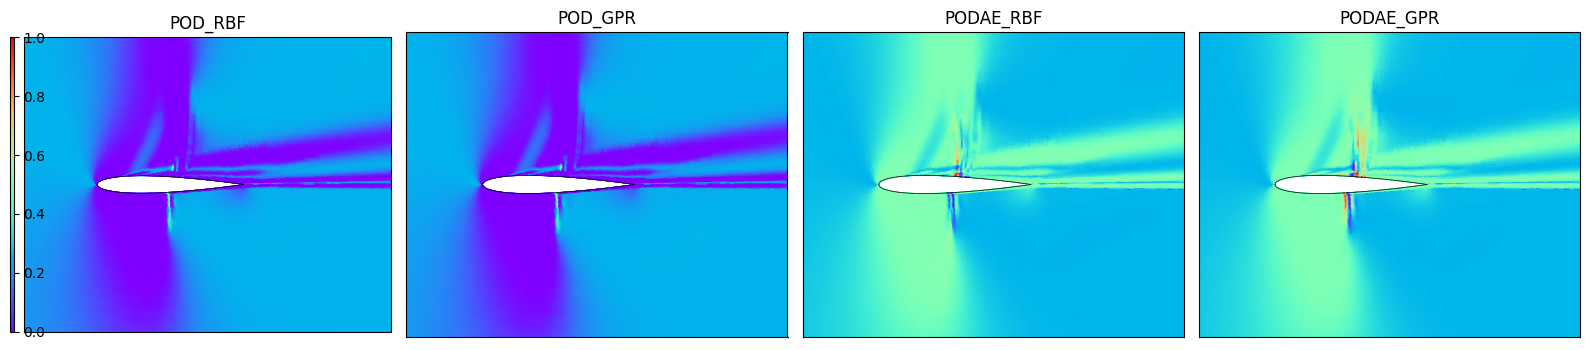

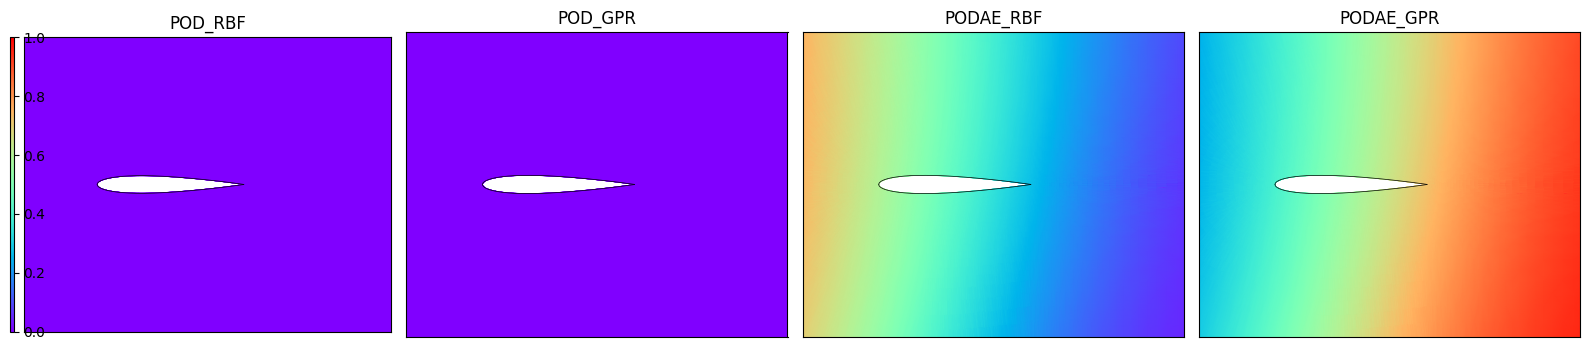

In [16]:
for mrom in multiroms.values():
    weights_list = []
    for rom in roms_dict.keys():
        weights_list.append(mrom.weights_predict[rom].flatten())
    plot_multiple_internal(data, weights_list, list(roms_dict.keys()),
        figsize=None, logscale=False, lim_x=(-0.5, 2), lim_y=(-1, 1), different_cbar=False, clims=[0, 1])

We can immediately see that the standard aggregation algorithm is "activating" the nonlinear reduction approaches (PODAE) in the spatial regions close to the shock and to the wake, while in the rest part of the domain the weights are 50% for POD methods and 50% for PODAE methods.
The ANN strategy instead converges to weights with less space-dependency. This highly depends on the architecture of the ANN, and on all the hyperparameters (activation function, learning rate, weight decay).

### What's next?
There's still a lot to do like:
- improving the training of the ANN by adding a negative loss contribution depending on the spatial variability of the weights. In this way we try to enforce more space variability;
- try to combine FOM and ROM together (multifidelity aggregation).